# Chapter 2: Visual Programming in Python

## Notes

- Tkinter is a GUI library included as part of the Python Standard
  Library
- It provides the basic graphical widgets for building graphical user
  interfaces, e.g.
  - Windows
  - Buttons
  - Radio Buttons
  - Check boxes
  - Entry fields
  - List boxes
  - Combo boxes
  - and more…
- A simple two-button tkinter program can looks like below

``` python
import tkinter as tk
from tkinter import messagebox

# Set up the window
root = tk.Tk()
root.geometry("100x300+300+300")

# Write a slogan out to a message box
def display_slogan():
    messagebox.showinfo("Our Message", "Tkinter is easy to use")

# create a button to call the message
slogan = tk.Button(root, text="Hello", command=display_slogan)
slogan.pack(side=tk.LEFT, padx=10)

# create a quit button
quit_button = tk.Button(root, text="QUIT", fg="red", command=quit)
quit_button.pack(side=tk.RIGHT, padx=10)
```

- The code above can also be found in
  [01-slogan.py](Examples/01-slogan/01-slogan.py)

- `tk.Tk()` sets up the main window of the program

- A button can then be created via `tk.Button`

  - Most widgets accept a parent widget
  - i.e. The parent widget *contains* the child widget
  - We then define `text` which defines the text shown on the label
    - We can colour the text with the `fg` (foreground) parameter
  - `Button` has a handle for a callback which is executed when the
    button is clicked
  - Here the `command` argument
  - We link the `Hello` button to `display_slogan` which is a simple
    function that displays a message box
  - The `QUIT` button is linked to the python `quit` function which is a
    simple built-in for exiting a python program
    - it is designed for interpreteer sessions and in general one should
      prefer `sys.exit` from the `sys` built-in

- Once created the placement of widgets can be controlled by setting the
  layout

  - Two common layouts are `pack` and `grid`
    - Here we use the `tk` special constant `tk.LEFT` and `tk.RIGHT` to
      control the placement of the buttons - This makes the buttons
      appear side-by-side
    - `padx` (and it’s partner `pady`) control the amount of spacing
      between widgets

- A `tkinter.messagebox` is a dialog that pops up and yanks focus

  - A user must acknowledge the message box before they can continue

- The program above should look something like below when run

  <figure>
  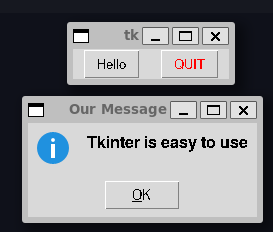
  <figcaption aria-hidden="true">A simple window with two buttons, one of
  which opens a message box</figcaption>
  </figure>

### Importing Fewer Names

- Tkinter is designed to consist of a number of different submodules
- Each submodule is designed to be explicitly loaded to avoid memory
  consumption
  - If we try to use `messagebox` without explicitly importing the
    submodule it won’t load

### Creating an Object-Oriented Version

- In the program above the function to be executed by a button is passed
  to the constructor as a handle
- An Object-Oriented approach, might be to provide a `command` method on
  the `Button` class
  - The `command` method is *overwritten* or *implemented* by subclasses
    of different functionality
- We start by defining the *abstact* base class
  - This is a class that effectively defines *what* our new
    `DerivedButton` classes should look like
  - We provide an `__init__` constructor that acts as a pass through
    constructor for the `tk.Button` base class
    - `**kwargs` in the function signature captures *keyword arguments*
      of the form `key=value` provided in the call
      - These are stored in the variable `kwargs` as a dict
      - These are then unpacked via *back* into `key=value` arguments
        via the `**` unpacking syntax
  - We define an abstract method `command` that is the implementation
    for what `command` is executed when a button is called
    - The `__init__` call links this method to the base-class `Button`
      and it’s `command` interface
- The abstract class is not intended to be instantiated directly

``` python
import tkinter as tk

class DerivedButton(tk.Button):
    def __init__(self, root, **kwargs):
        super().__init__(root, **kwargs)
        super().config(command=self.command)

    # abstract method to by overwritten by children
    def command(self):
        pass
```

- Now we can define our `OKButton` and `QuitButton` as concrete
  subclasses of `DerivedButton`
  - These should be directly instantiated

``` python
from tkinter import messagebox

class OKButton(DerivedButton):
    def __init__(self, root):
        super().__init__(root, text="OK")

    def command(self):
        messagebox.showinfo("Our Message", "Tkinter is easy to use")

class QuitButton(DerivedButton):
    def __init__(self, root):
        super().__init__(root, text="Quit", fg="red")

    def command(self):
        quit()
```

- Here the base class `Button` is hooked into the `DerivedButton`
  `command` method by the `DerivedButton` base class
  - Now when we create an `OKButton` and `QuitButton` we redefine the
    `command` function for those specific classes
  - Now when we click the button the redefined `command` method is
    invoked
- This an example of *polymorphism*
- Building the UI is then pretty simple since the classes mostly handle
  constructing themselves
- The complete code can be found in
  [02-derived-button.py](Examples/02-derived-button/02-derived-button.py)

``` python
def buildUI():
    root = tk.Tk()
    root.geometry("300x100+300+300")

    slogan = OKButton(root)
    slogan.pack(side=tk.LEFT, padx=10)

    button = QuitButton(root)
    button.pack(side=tk.RIGHT, padx=10)

    root.mainloop()
```

- You could also put the `pack` methods inside the classes
  - Potentially as an `__init__` parameter

### Using Message Boxes

- As discussed the message box creates a dialog window that must be
  acknowledged
- There are different ways of calling the message box which modifies how
  it is displayed
- The code below creates a simple window with three buttons which can
  each call a different message box
  - We’ve already seen `showinfo`

  - `showwarning` styles the message as a warning

    <figure>
    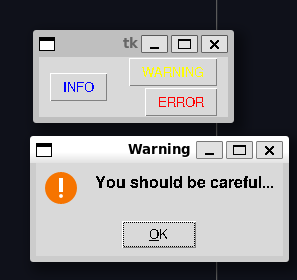
    <figcaption aria-hidden="true">A warning box, on Ubuntu this contains an
    orange exclamation mark</figcaption>
    </figure>

  - `showerror` styles the message as an error

    <figure>
    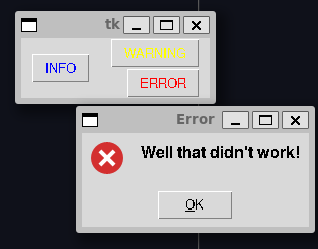
    <figcaption aria-hidden="true">An error box, on Ubuntu this contains a
    red cross symbol</figcaption>
    </figure>

``` python
import tkinter as tk
import tkinter.messagebox

# Set up the window
root = tk.Tk()


# Write a slogan out to a message box
def display_info():

    tk.messagebox.showinfo("Info", "Consider yourself informed")


def display_warning():
    tk.messagebox.showwarning("Warning", "You should be careful...")


def display_error():
    tk.messagebox.showerror("Error", "Well that didn't work!")


info_button = tk.Button(root, text="INFO", fg="Blue", command=display_info)
info_button.pack(side=tk.LEFT, padx=10)

warning_button = tk.Button(root, text="WARNING", fg="Yellow", command=display_warning)
warning_button.pack(padx=10)

error_button = tk.Button(root, text="ERROR", fg="red", command=display_error)
error_button.pack(side=tk.RIGHT, padx=10)

root.mainloop()
```

- The code is contained in
  [03-messagebox.py](Examples/03-messagebox/03-messagebox.py)

- Note that `tk` uses the native windowing system of the Operating
  System it runs on

  - This means that `tk` may look different on your program

- The message box also provides dialogs for standard prompts to the user

  - `askquestion` for asking a question

    <figure>
    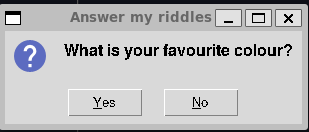
    <figcaption aria-hidden="true">The <code>askquestion</code> dialog looks
    shows a question mark with <em>yes</em> and <em>no</em>
    buttons</figcaption>
    </figure>

  - `askyesno` for asking a yes or no question

    <figure>
    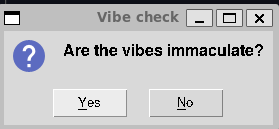
    <figcaption aria-hidden="true">The <code>askyesno</code> dialog looks
    identical to the <code>askquestion</code> dialog on Ubuntu</figcaption>
    </figure>

  - `askyesnocancel` for asking a yes or no question with the option to
    cancel

    <figure>
    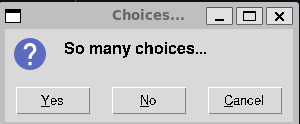
    <figcaption aria-hidden="true">The <code>askyesnocancel</code> dialog
    looks like the <code>askyesno</code> but has an additional
    <em>cancel</em> button</figcaption>
    </figure>

  - `askokcancel` for asking for approval

    <figure>
    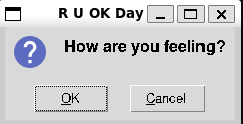
    <figcaption aria-hidden="true">The <code>askokcancel</code> shows a
    question mark with <em>ok</em> and <em>cancel</em> buttons</figcaption>
    </figure>

  - `askretrycancel` for asking to retry an operation

    <figure>
    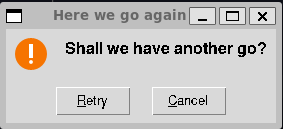
    <figcaption aria-hidden="true">The <code>askretrycancel</code> looks
    like <code>askokcancel</code> but has a warning exclamation mark rather
    than a question mark</figcaption>
    </figure>

- Again we have a program that contains buttons that let’s you look at
  all these dialogs (See
  [04-questioning-message-box.py](Examples/04-questioning-messagebox/04-questioning-message-box.py))

``` python
import tkinter as tk
import tkinter.messagebox


# Write a slogan out to a message box
def ask_ok():
    tk.messagebox.askokcancel("R U OK Day", "How are you feeling?")


def ask_question():
    tk.messagebox.askquestion("Answer my riddles", "What is your favourite colour?")


def ask_retry():
    tk.messagebox.askretrycancel("Here we go again", "Shall we have another go?")


def ask_yesno():
    tk.messagebox.askyesno("Vibe check", "Are the vibes immaculate?")


def ask_yesnocancel():
    tk.messagebox.askyesnocancel("Choices...", "So many choices...")


button_params = [
    (ask_ok, "Ok"),
    (ask_question, "Question"),
    (ask_retry, "Retry"),
    (ask_yesno, "Yes / No"),
    (ask_yesnocancel, "Yes / No / Cancel"),
]

root = tk.Tk()
for cmd, label in button_params:
    but = tk.Button(root, text=label, command=cmd)
    but.pack(padx=10, pady=10)

root.mainloop()
```

### File Dialogs

- Like with message boxes tkinter provides a pre-made dialog for
  selecting files

  - Called `filedialog`

- `filedialog` has a number of methods for interacting with files

- `askopenfilename` opens a dialog for selecting a file by name

  - Has an `ok` and `cancel` button
  - Pressing `ok` returns a sring with the full path of the selected
    file
  - Pressing `cancel` returns an empty string

- Below is an example of a file dialog

  <figure>
  <embed src="attachment:Examples/05-file-dialog/05-file-dialog.py" />
  <figcaption aria-hidden="true">The dialog opened by
  <code>filedialog.askopenfilename</code>. A menu is shown to select files
  from the specified directory along with an <em>ok</em> and
  <em>cancel</em> button. A dropdown menu can be used to narrow the choice
  of file types</figcaption>
  </figure>

  - The full code is in [05-file-dialog.py]()

``` python
import tkinter as tk
import tkinter.filedialog

fname = tk.filedialog.askopenfilename()
print(fname)
```

- Other methods on the `filedialog` include,

  - `askdirectory`
    - Asks for a directory and returns the path
  - `askopenfile`
    - Ask for a file to open and return the opened file stream
  - `askopenfilenames` and `askopenfiles` are like the non-plural
    variants but return multiple files
  - `asksaveasfile` and `asksaveasfilename` ask for a filename to save
    as
    - `asksaveasfile` returns the opened file
    - `asksaveasfilename` returns the file name

### The Pack Layout Manager

- `pack` is the most basic tkinter layout manager

- It’s use is generally discouraged in favour of layout managers like
  `grid` but for simple use cases it can be useful to know

- It has a number of layout options

  | Parameter | Description |
  |---------|---------------------------------------------------------------|
  | `fill=tk.X` | Stretch widget to fill frame in the X direction |
  | `fill=tk.Y` | Stretch widget to fill frame in the Y direction |
  | `fill=tk.BOTH` | Stretch widget to fill in both directions |
  | `side=tk.LEFT` | Position widget to left side of the frame |
  | `side=tk.RIGHT` | Position widget to right side of the frame |
  | `expand=n` | Distribute remaining space in the frame among all widgets when `n` is nonzero |
  | `anchor` | Where the widget is placed within the packing box. Options are `tk.CENTER` (default), `tk.N`, `tk.E`, `tk.S`, `tk.W` or combinations e.g `tk.NE` |
  | `padX, padY` | Number of pixels to pad the X and Y dimensions respectively |

- Below is a simple example showing how to put together a simple dialog
  using multiple components laid out with `pack`

  <figure>
  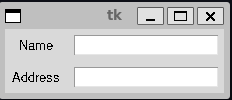
  <figcaption aria-hidden="true">A simple two-row example using the packed
  layout. Each row consists of a <code>tk.Label</code> left-aligned on the
  left, and a <code>tk.Entry</code> on the right stretched to fill the
  remaining space</figcaption>
  </figure>

``` python
import tkinter as tk

root = tk.Tk()

# Create first row, taking up the entire X dimension
first_row = tk.Frame(root)
first_row.pack(fill=tk.X)

# Add widgets to the first row
label_1 = tk.Label(first_row, text="Name", width=7)
label_1.pack(side=tk.LEFT, padx=5, pady=5)

entry_1 = tk.Entry(first_row)
entry_1.pack(fill=tk.X, padx=5, pady=5)  # fill the remaining X space

# Create the second row, again taking the entire X dimension
second_row = tk.Frame(root)
second_row.pack(fill=tk.X)

# Add widgets to the second row
label_2 = tk.Label(second_row, text="Address", width=7)
label_2.pack(side=tk.LEFT, padx=5, pady=5)

entry_2 = tk.Entry(second_row)
entry_2.pack(fill=tk.X, padx=5, pady=5)

root.mainloop()
```

### The `ttk` Library

- Tkinter and the underlying Tk Windowing toolkit is a relatively old
  GUI framework

  - Some of it’s widgets look outdated
  - Also the default set of widgets is missing some common modern-style
    widgets

- Newer versions of Tk often also include a more modern set of widgets
  in the `ttk` library

  - These are kept in a separate library to keep the two different
    widget styles distinct

- `ttk` also modifies how Tk manages state

  - Aims to decouple graphics from the logic of managing the state

- Some of the new widgets in `ttk` includ

  - `Button`
  - `CheckButton`
  - `Entry`
  - `Frame`
  - `Label`
  - `LabelFrame`
  - `MenuButton`
  - `PanedWindow`
  - `RadioButton`
  - `Scale`
  - `Scrollbar`

- To use the new style widgets, simply import and use the appropriate
  `tkinter.ttk` widgets

- For example, using the modernised button we simply replace `tk.Button`
  with `ttk.Button`

  - There is some caveat in that `ttk` uses a different form for styling
  - `foreground` and `background` etc. are no longer part of the
    constructor
  - Instead you register `Style` objects and then invoke them on the
    object

- For example, the new code for the quit button is,

  ``` python
    ttk.Style().configure("W.TButton", foreground="red")
    quit_button = ttk.Button(root, text="QUIT", command=quit, style="W.TButton")
    quit_button.pack(side=tk.RIGHT, padx=10)
  ```

- The full code example is given in
  [07-ttk-button](Examples/07-ttk-button/07-ttk-button.py)

``` python
import tkinter as tk
import tkinter.messagebox
import tkinter.ttk as ttk

# Set up the window
root = tk.Tk()


# Write a slogan out to a message box
def display_slogan():
    tk.messagebox.showinfo("Our Message", "Tkinter is easy to use")


# create a button to call the message
slogan = ttk.Button(root, text="Hello", command=display_slogan)
slogan.pack(side=tk.LEFT, padx=10)

# create a quit button
ttk.Style().configure("W.TButton", foreground="red")
quit_button = ttk.Button(root, text="QUIT", command=quit, style="W.TButton")
quit_button.pack(side=tk.RIGHT, padx=10)

root.mainloop()
```

- The resulting window looks like

  <figure>
  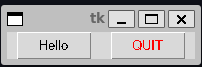
  <figcaption aria-hidden="true">The basic two-button widget updated to
  use the <code>ttk</code> buttons</figcaption>
  </figure>

### Responding to User Input

## Summary